In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense

In [2]:
red = pd.read_csv(r"C:\Users\KIIT\Downloads\redwinequality.csv", sep=';')
white = pd.read_csv(r"C:\Users\KIIT\Downloads\whitewinequality.csv", sep=';')
red['type'] = 1
white['type'] = 0
wines = pd.concat([red, white], ignore_index=True)
wines.dropna(inplace=True)

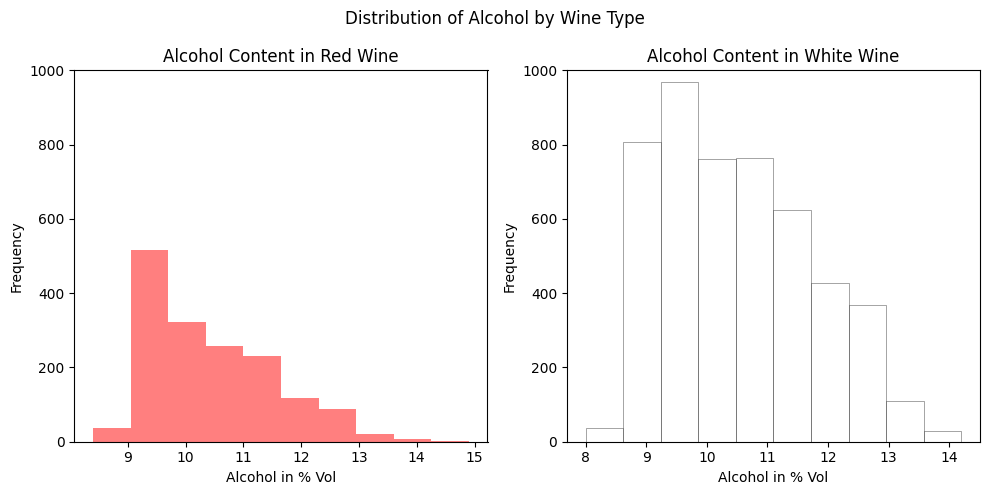

In [3]:
#Plotting Distribution of Alcohol  
#We will use matplotlib to create a visual representation of the distribution of alcohol 
#content for red and white wines.We will create a histogram for each wine type (red and white) 
#with a specified number of bins (10).
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].hist(wines[wines['type'] == 1].alcohol, bins=10, facecolor='red', alpha=0.5, label='Red wine')
ax[1].hist(wines[wines['type'] == 0].alcohol, bins=10, facecolor='white', edgecolor='black', lw=0.5, alpha=0.5, label='White wine')
for a in ax:
    a.set_ylim([0, 1000])
    a.set_xlabel('Alcohol in % Vol')
    a.set_ylabel('Frequency')
ax[0].set_title('Alcohol Content in Red Wine')
ax[1].set_title('Alcohol Content in White Wine')
fig.suptitle('Distribution of Alcohol by Wine Type')
plt.tight_layout()
plt.show()

In [4]:
#Splitting Data into Training and Testing Sets
#We will split our dataset into training and testing
#X contains all columns except the target variable (type), which is represented by y.
#train_test_split(): splits the dataset into training (66%) and testing (34%) sets.
#random_state=45:ensures that the split is reproducible.
X = wines.iloc[:, :-1]
y = wines['type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.34, random_state=45)

In [6]:
#Creating Neural Network Model
#The function Sequential() defines a neural network with 3 layers:
#Input layer: Dense(12) with 12 neurons and ReLU activation function where input_dim=12
#matches the number of features (columns) in the input data.#Hidden layer: Dense(9) with 9 
#neurons and ReLU activation.#Output layer: Dense(1) with a single neuron and a sigmoid ]
#activation function since this is a binary classification problem (predicting red or white wine)
#The model is compiled using the binary crossentropy loss function and the Adam optimizer.
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

# ───────────────────────────────────────────────
# Option 1: Sequential model with list style (cleanest & most readable)
# ───────────────────────────────────────────────

model = Sequential([
    Input(shape=(12,)),               # ← modern & warning-free way to define input shape
    Dense(12, activation='relu'),
    Dense(9, activation='relu'),
    Dense(1, activation='sigmoid')
])

# ───────────────────────────────────────────────
# Option 2: Using .add() style (very common too)
# ───────────────────────────────────────────────
# model = Sequential()
# model.add(Input(shape=(12,)))
# model.add(Dense(12, activation='relu'))
# model.add(Dense(9, activation='relu'))
# model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),   # you can tune lr if needed
    metrics=['accuracy']
)

# ───────────────────────────────────────────────
# Quick model summary (very useful to check)
# ───────────────────────────────────────────────
model.summary()

# ───────────────────────────────────────────────
# Example: how you would normally train it
# (uncomment and adapt to your real data)
# ───────────────────────────────────────────────
# X_train = np.random.rand(1000, 12)          # ← your features
# y_train = np.random.randint(0, 2, 1000)     # ← your binary labels (0 or 1)

# history = model.fit(
#     X_train, y_train,
#     epochs=50,
#     batch_size=32,
#     validation_split=0.2,
#     verbose=1
# )

# After training you can evaluate / predict like this:
# loss, acc = model.evaluate(X_test, y_test)
# predictions = model.predict(X_new)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 12)                  │             156 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 9)                   │             117 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              10 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 283 (1.11 KB)

 Trainable params: 283 (1.11 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
#Training the Model
#We train the model using the training data (X_train, y_train) for 3 epochs with a batch size of 1.
model.fit(X_train, y_train, epochs=3, batch_size=1, verbose=1)

Epoch 1/3
4288/4288 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.9160 - loss: 0.3614
Epoch 2/3
4288/4288 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9443 - loss: 0.1732
Epoch 3/3
4288/4288 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9494 - loss: 0.1392


In [8]:
#We make predictions using the trained model on the test data (X_test) and 
#get the predicted probabilities for each wine sample. We then convert these
#probabilities into binary labels (1 for Red wine, 0 for White wine) and
#display the wine type prediction for the first 12 samples.
y_pred = model.predict(X_test)
y_pred_labels = (y_pred >= 0.5).astype(int)
for prediction in y_pred_labels[:12]:
    wine_type = "Red wine" if prediction == 1 else "White wine"
    print(f"Prediction: {wine_type}")

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Prediction: White wine
Prediction: White wine
Prediction: White wine
Prediction: White wine
Prediction: White wine
Prediction: Red wine
Prediction: Red wine
Prediction: White wine
Prediction: Red wine
Prediction: White wine
Prediction: White wine
Prediction: White wine


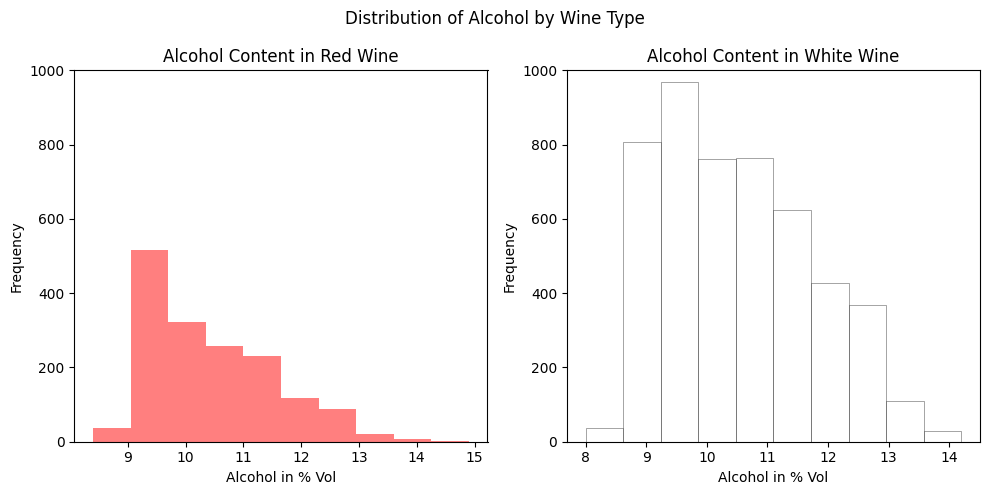

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].hist(wines[wines['type'] == 1].alcohol, bins=10, facecolor='red', alpha=0.5, label='Red wine')
ax[1].hist(wines[wines['type'] == 0].alcohol, bins=10, facecolor='white', edgecolor='black', lw=0.5, alpha=0.5, label='White wine')
for a in ax:
    a.set_ylim([0, 1000])
    a.set_xlabel('Alcohol in % Vol')
    a.set_ylabel('Frequency')
ax[0].set_title('Alcohol Content in Red Wine')
ax[1].set_title('Alcohol Content in White Wine')
fig.suptitle('Distribution of Alcohol by Wine Type')
plt.tight_layout()
plt.show()